## Importing Necessary Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm
from google.colab import files
uploaded = files.upload()
!apt-get install -y fonts-liberation

Saving data.tsv to data.tsv
Saving results_VH.tsv to results_VH.tsv
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


### Setting Theme

In [2]:
sns.set_theme()
sns.set_theme(context='notebook',style='whitegrid',palette='viridis',font='Liberation Serif',font_scale=1,color_codes=True)


## Loading Data and Metadata

In [3]:
# load metadata file and SVM results file
metadata = pd.read_csv("data.tsv", sep = "\t")
VH = pd.read_csv("results_VH.tsv", sep = "\t")
# extract dataframes for false positives and false negatives
FP = VH[(VH["Class"] == 0) & (VH["Prediction"] == 1)]
TP = VH[(VH["Class"] == 1) & (VH["Prediction"] == 1)]
FN = VH[(VH["Class"] == 1) & (VH["Prediction"] == 0)]
TN = VH[(VH["Class"] == 0) & (VH["Prediction"] == 0)]

fp_ids = FP["UniProt_ID"]
fn_ids = FN["UniProt_ID"]

fp_meta = metadata[metadata["UniProt_ID"].isin(fp_ids)]
fn_meta = metadata[metadata["UniProt_ID"].isin(fn_ids)]


## Plotting False Positives and False Negatives Kingdom Distribution

/tmp/ipython-input-2861768391.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fp_percent.index, y=fp_percent.values, ax=ax2, palette="viridis")
/tmp/ipython-input-2861768391.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


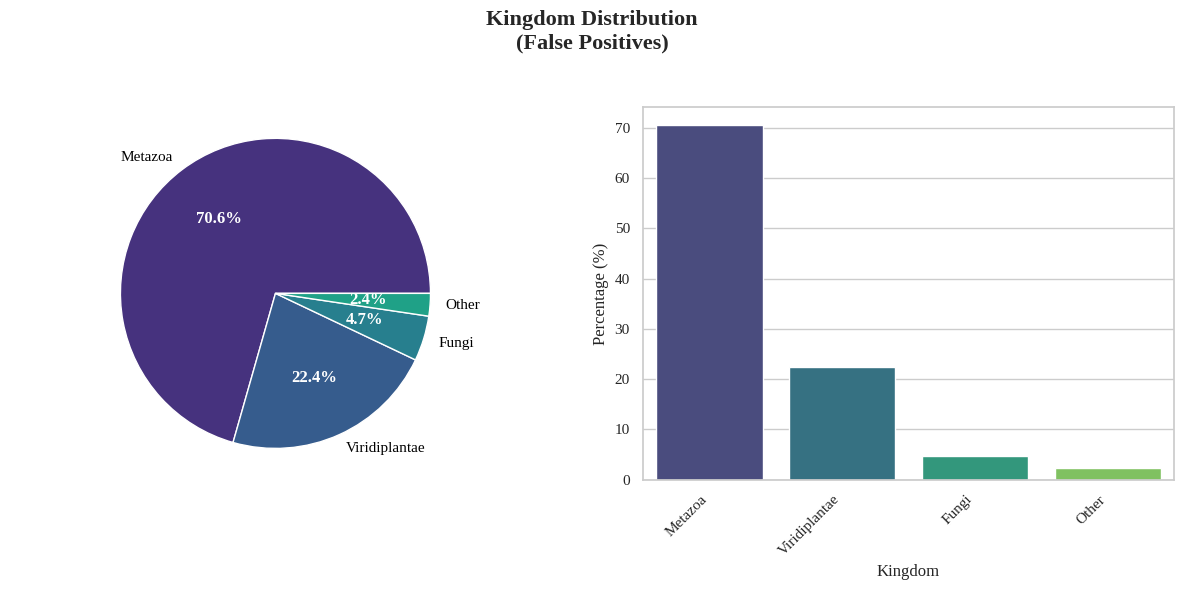

In [4]:
#Count the values and percentages
fp_kingdom = fp_meta['Kingdom'].value_counts()
fp_percent = fp_kingdom / fp_kingdom.sum() * 100

#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Positives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fp_kingdom, labels=fp_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(x=fp_percent.index, y=fp_percent.values, ax=ax2, palette="viridis")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Kingdom")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig("t_kingdom.pdf", dpi=1000, format="pdf")
#plt.clf()

In [5]:
#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Positives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fp_kingdom, labels=fp_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(x=fp_percent.index, y=fp_percent.values, ax=ax2, palette="viridis")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Kingdom")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')

#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("FP_kingdom.png", dpi=1000, format="png")
plt.clf()

/tmp/ipython-input-712411114.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fp_percent.index, y=fp_percent.values, ax=ax2, palette="viridis")
/tmp/ipython-input-712411114.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 1200x600 with 0 Axes>

/tmp/ipython-input-1096785451.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fn_percent.index, y=fn_percent.values, ax=ax2, palette="viridis")
/tmp/ipython-input-1096785451.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


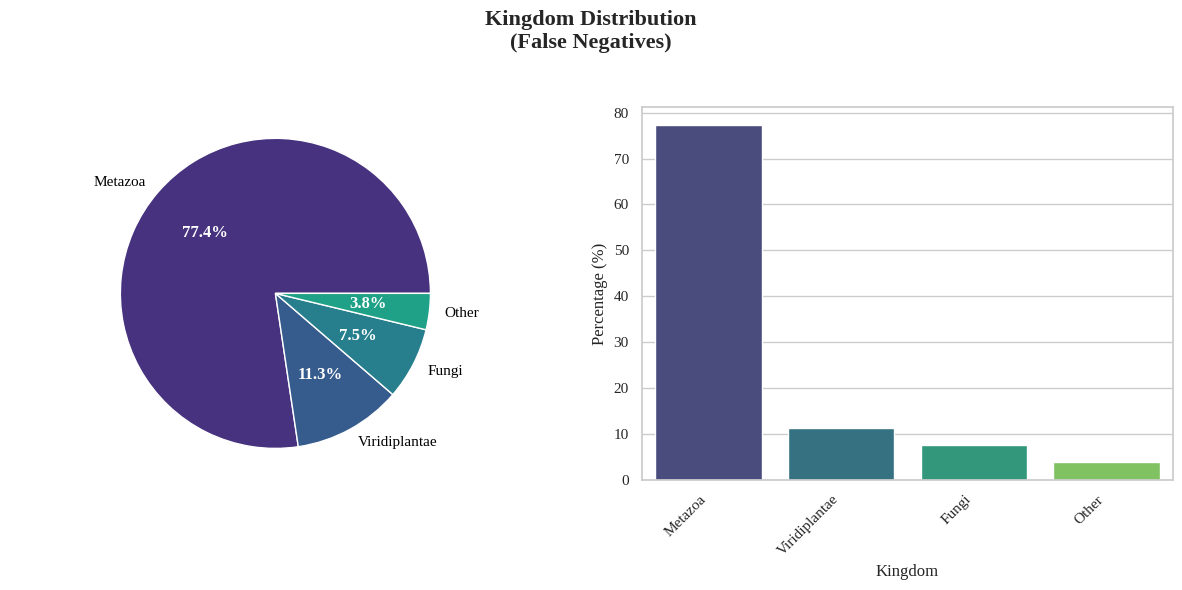

In [6]:
#Count the values and percentages
fn_kingdom = fn_meta['Kingdom'].value_counts()
fn_percent = fn_kingdom / fn_kingdom.sum() * 100

#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fn_kingdom, labels=fn_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(x=fn_percent.index, y=fn_percent.values, ax=ax2, palette="viridis")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Kingdom")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig("t_kingdom.pdf", dpi=1000, format="pdf")
#plt.clf()

In [7]:
#Divide the plot in two
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle("Kingdom Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

#Create the pie plot and format the labels
wedges, texts, autotexts = ax1.pie(fn_kingdom, labels=fn_kingdom.index, autopct='%.1f%%',)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

#Create the bar plot
sns.barplot(x=fn_percent.index, y=fn_percent.values, ax=ax2, palette="viridis")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Kingdom")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


#Display the plots
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("FN_kingdom.png", dpi=1000, format="png")
plt.clf()

/tmp/ipython-input-1579750559.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fn_percent.index, y=fn_percent.values, ax=ax2, palette="viridis")
/tmp/ipython-input-1579750559.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 1200x600 with 0 Axes>

## Plotting False Positives and False Negatives Species Distribution

/tmp/ipython-input-1806477505.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1806477505.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


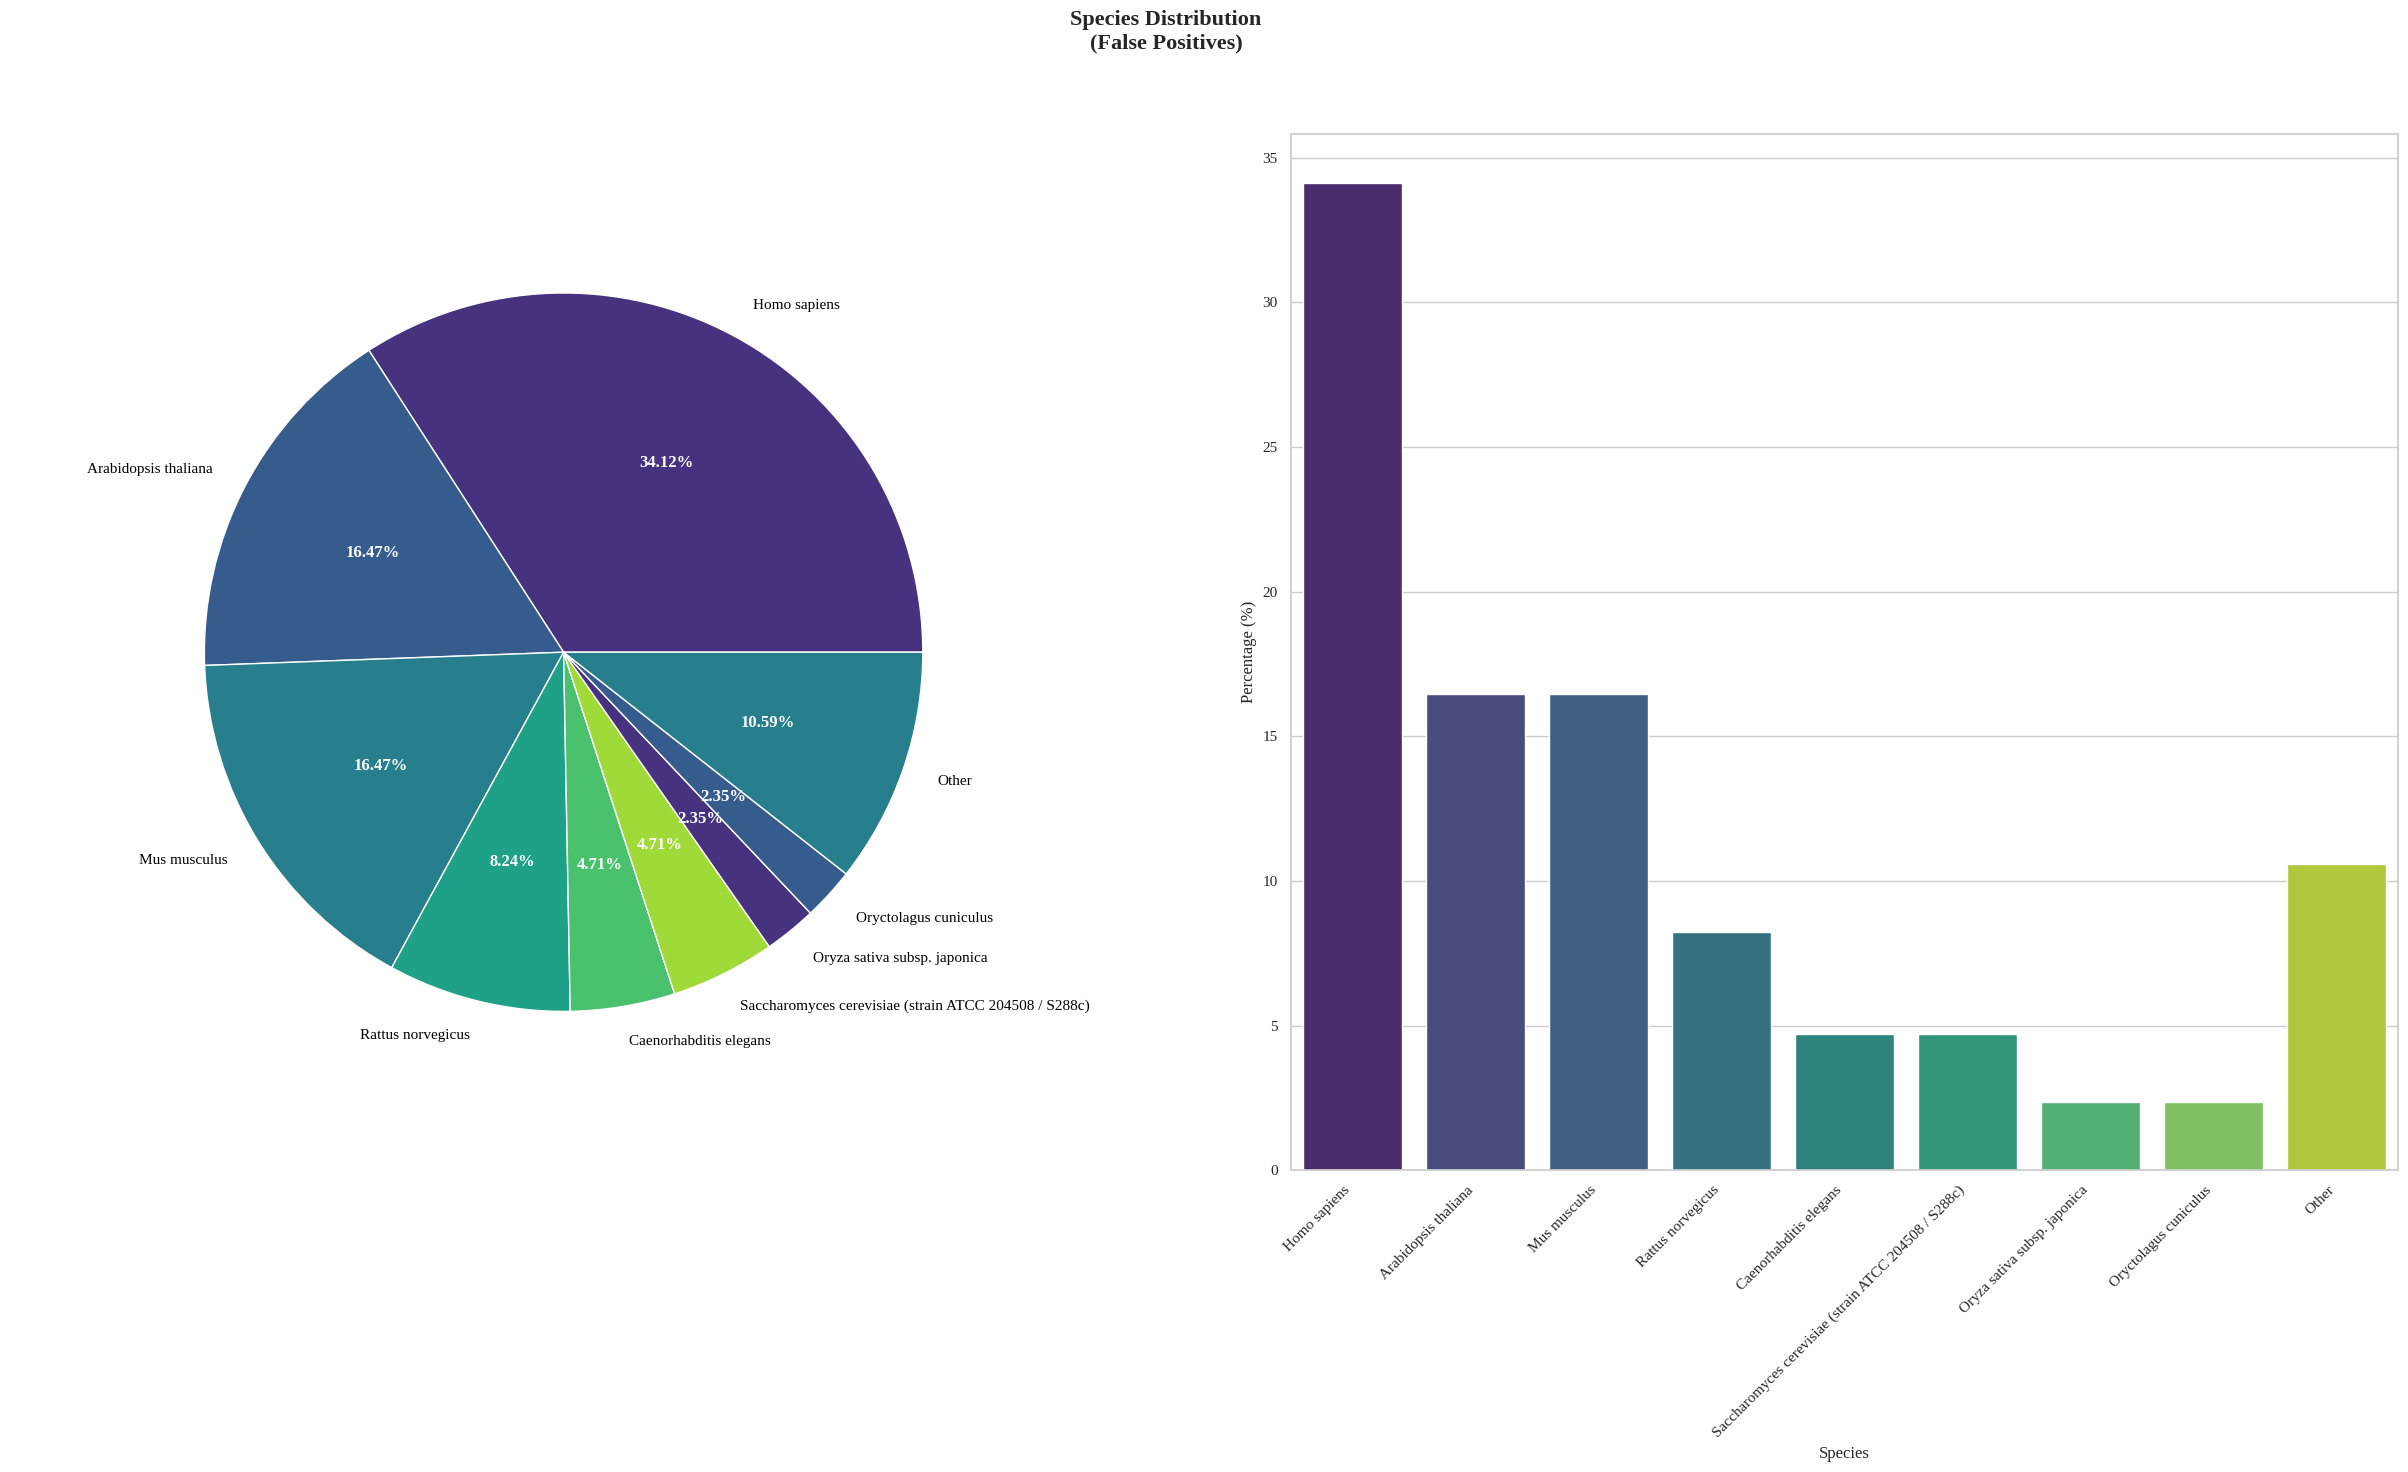

In [8]:
# Count values and percentages
fp_species = fp_meta['Species'].value_counts()
fp_percent = fp_species / fp_species.sum() * 100

# Group small categories (<= 2.3%) into "Other"
threshold = 2.0
small_cats = fp_percent[fp_percent <= threshold]

if len(small_cats) > 0:
    other_sum = small_cats.sum()
    # Keep large categories
    fp_species_grouped = fp_species[fp_percent > threshold].copy()
    # Add "Other" category
    fp_species_grouped["Other"] = (other_sum / 100) * fp_species.sum()
else:
    fp_species_grouped = fp_species.copy()

# Recalculate percentages after grouping
fp_percent_grouped = fp_species_grouped / fp_species_grouped.sum() * 100

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Positives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fp_species_grouped,
    labels=fp_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fp_percent_grouped.index,
    y=fp_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig("t_species.pdf", dpi=1000, format="pdf")
#plt.clf()

In [9]:
# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Positives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fp_species_grouped,
    labels=fp_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')
for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fp_percent_grouped.index,
    y=fp_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("FP_species.png", dpi=1000, format="png")
plt.clf()

/tmp/ipython-input-608733278.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-608733278.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 2500x1500 with 0 Axes>

/tmp/ipython-input-2912708706.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-2912708706.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


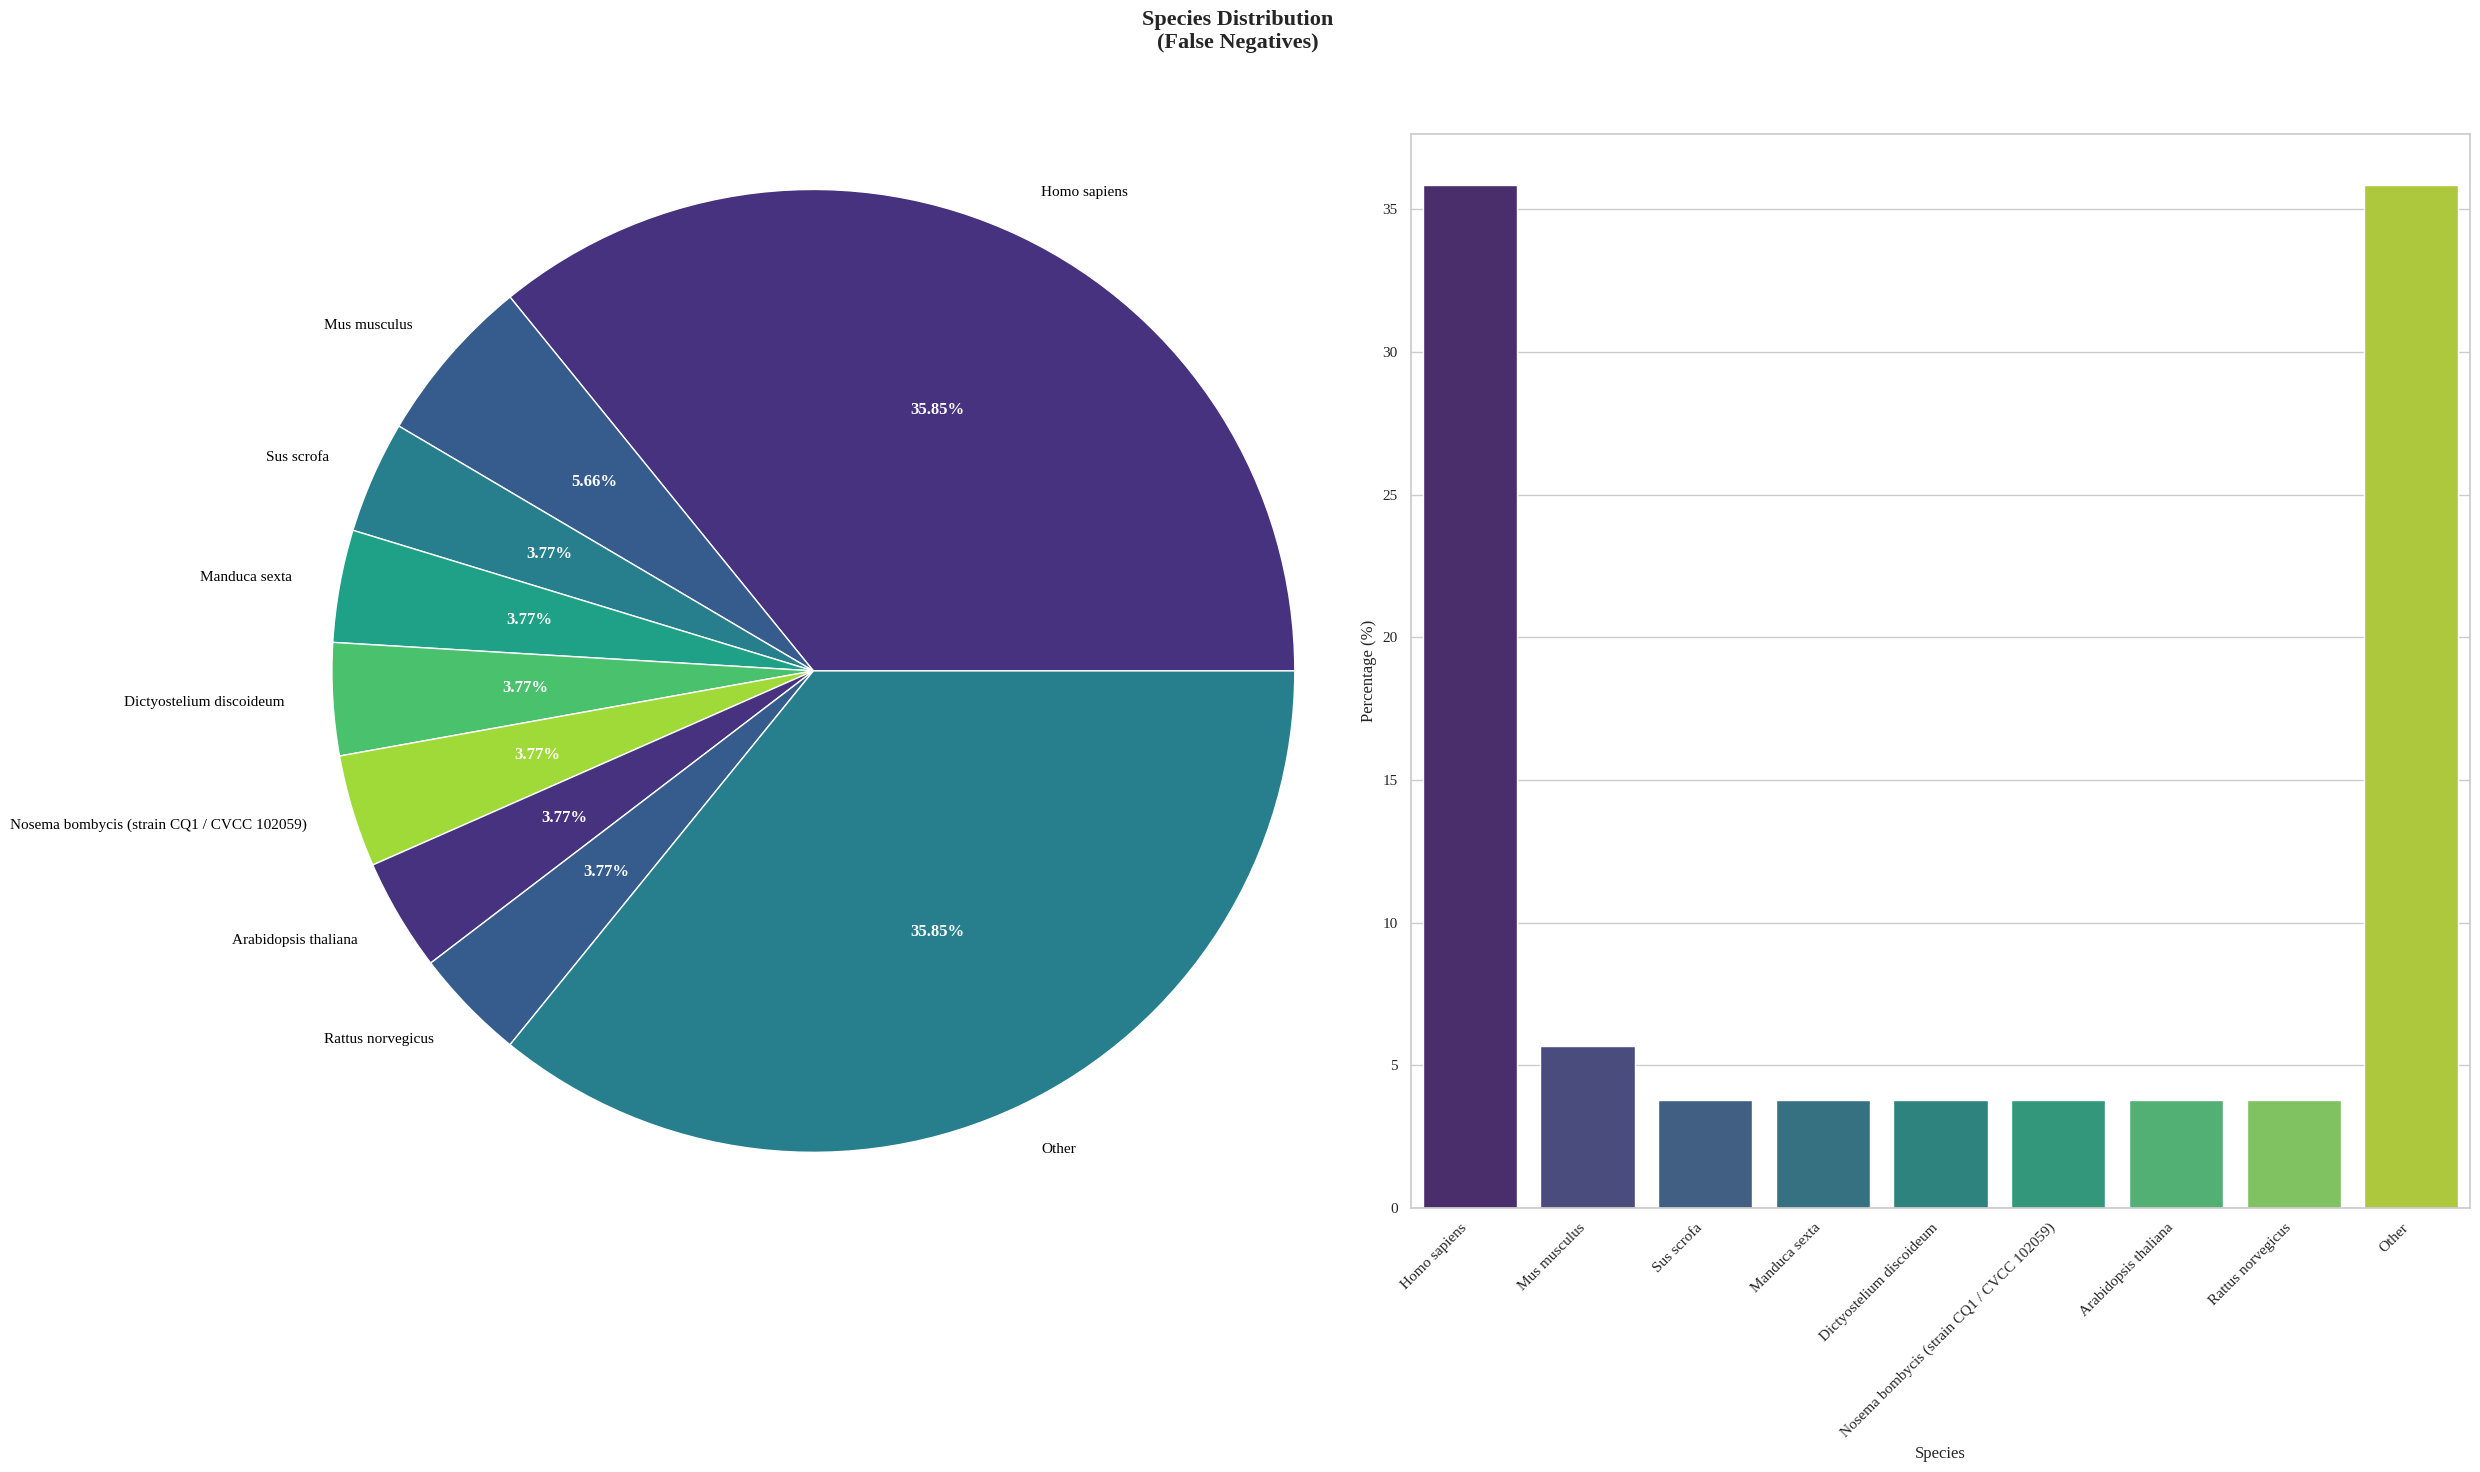

In [10]:
# Count values and percentages
fn_species = fn_meta['Species'].value_counts()
fn_percent = fn_species / fn_species.sum() * 100

# Group small categories (<= 2.3%) into "Other"
threshold = 2.0
small_cats = fn_percent[fn_percent <= threshold]

if len(small_cats) > 0:
    other_sum = small_cats.sum()
    # Keep large categories
    fn_species_grouped = fn_species[fn_percent > threshold].copy()
    # Add "Other" category
    fn_species_grouped["Other"] = (other_sum / 100) * fn_species.sum()
else:
    fn_species_grouped = fn_species.copy()

# Recalculate percentages after grouping
fn_percent_grouped = fn_species_grouped / fn_species_grouped.sum() * 100

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fn_species_grouped,
    labels=fn_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fn_percent_grouped.index,
    y=fn_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig("t_species.pdf", dpi=1000, format="pdf")
#plt.clf()

In [11]:
# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(25, 15))
fig.suptitle("Species Distribution\n(False Negatives)", fontsize=16, fontweight='bold')

# pie plot
wedges, texts, autotexts = ax1.pie(
    fn_species_grouped,
    labels=fn_species_grouped.index,
    autopct='%.2f%%'
)
ax1.axis('equal')

for text in texts:
    text.set_color("black")
    text.set_fontsize(11)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")

# bar plot
sns.barplot(
    x=fn_percent_grouped.index,
    y=fn_percent_grouped.values,
    ax=ax2,
    palette="viridis"
)
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Species")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout(rect=[0, 0, 1, 0.95])

plt.savefig("FN_species.png", dpi=1000, format="png")
plt.clf()

/tmp/ipython-input-1874989505.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-1874989505.py:29: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=45, ha='right')


<Figure size 2500x1500 with 0 Axes>

## FPR: all vs TM Helix

In [12]:
fp_tm = FP[FP['TM_Helix'] == True]
negatives = VH[VH['Class'] == 0]
fpr = len(FP['UniProt_ID']) / (len(negatives['UniProt_ID']))
fpr_tm = len(fp_tm['UniProt_ID']) / (len(negatives[negatives['TM_Helix'] == True]['UniProt_ID']))
print("FPR is overall "+str(fpr)+".\nOver false positives carrying a trans membrane domain in the first 90 residues the FPR is "+str(fpr_tm))
print("The FPR of sequences carryng a TM domain is "+str(fpr_tm/fpr)+" times the FPR over all sequences.")

FPR is overall 0.04756575265808618.
Over false positives carrying a trans membrane domain in the first 90 residues the FPR is 0.2125984251968504
The FPR of sequences carryng a TM domain is 4.4695692450208435 times the FPR over all sequences.


## Extract SP15 subsequences (False Negatives) and export FASTA



In [13]:
output_file = "false_negatives_SP15.fasta"

with open(output_file, "w") as f:
    for idx, seq in enumerate(FN["SP_15"]):
        if not pd.isna(seq):
          f.write(">FN_" + str(idx) + "\n" + seq + "\n")

#print(output_file)
print("Total sequences exported:", len(FN))

Total sequences exported: 53
